In [1]:
import sys 
sys.path.append("/Users/shubham/Documents/Github/acceleration-flow-matching/src")


In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import LatentViT
from data_loader import train_dataset
from vae import SpatialVae
from tqdm import tqdm
from flow_matching import FlowMatchingSpatialLatent
from log_callback import TrainingCallback
from utils import visualize_samples
from torch.utils.data import DataLoader

In [3]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

In [4]:
cb = TrainingCallback(
    experiment_name="fm_mnist",
    model_type="fm",    # ← triggers trajectory saving too
    dataset="mnist",
    config={"lr": 1e-4, "batch_size": 256},
    save_every_n_epochs=1,
    checkpoint_every_n_epochs=1,
    sample_every_n_epochs=1,
)

def train_flowmatching(model_sampler: FlowMatchingSpatialLatent, train_loader, device='cuda', epochs=5, lr=1e-4):
    optimizer = Adam(model_sampler.model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model_sampler.model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}/{epochs}")

        for batch_idx, (x, y) in enumerate(progress_bar):
            
            loss, _ = model_sampler.forward_loss(x, y, criterion)

            optimizer.zero_grad()
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model_sampler.model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
            
            cb.on_batch_end(loss.item(), grad_norm.item())

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - DDPM Loss: {avg_loss:.6f}\n")

        cb.on_epoch_end(epoch, model_sampler, optimizer, device,
                    torch.arange(10, device=device))
        
        # if (epoch+1) % 10 == 1:
        #     torch.save({
        #         'epoch': epoch,
        #         'model_state_dict': model_sampler.model.state_dict(),
        #         'optimizer_state_dict': optimizer.state_dict(),
        #         'loss': avg_loss,
        #     }, f'{save_path}checkpoint_epoch_{epoch+1}.pth')
        #     print(f"✓ Saved checkpoint to Drive: epoch {epoch+1}, loss={avg_loss:.6f}")

    return model_sampler.model


────────────────────────────────────────────────────────────
  TrainingCallback initialised
  Run dir : experiments/fm_mnist_20260605_143709
  Model   : fm  |  Dataset: mnist
────────────────────────────────────────────────────────────



In [5]:
device = 'cpu'
model = LatentViT(latent_channels=16, embed_dim=192, depth=12, num_heads=3)
model.load_state_dict(torch.load('/Users/shubham/Downloads/ddpm_latent_model_150.pth', map_location=torch.device(device), weights_only=True))#['model_state_dict'])
model = model.to(device)

vae = SpatialVae(in_channels=1)
vae.load_state_dict(torch.load('spatial_vae_mnist.pth', map_location=torch.device('cpu'), weights_only=True))

model_flow = FlowMatchingSpatialLatent(model, vae=vae)


In [6]:
model = train_flowmatching(model_flow, train_loader, device=device, epochs=5, lr=1e-4)

DDPM Epoch 1/5:   0%|          | 0/235 [00:00<?, ?it/s]

DDPM Epoch 1/5: 100%|██████████| 235/235 [17:56<00:00,  4.58s/it, loss=1.72]


Epoch 1 - DDPM Loss: 1.793102

  Epoch   1 │ loss 1.793102 │ grad 0.1520 │ lr 1.00e-04 │ 1077.8s
    ✓ Checkpoint saved: best.pth
    ✓ Checkpoint saved: epoch_0001.pth
    ✓ Samples saved:    epoch_0001.png
    ✓ Trajectory saved: epoch_0001.png


DDPM Epoch 2/5: 100%|██████████| 235/235 [19:01<00:00,  4.86s/it, loss=1.76]


Epoch 2 - DDPM Loss: 1.756832

  Epoch   2 │ loss 1.756832 │ grad 0.1001 │ lr 1.00e-04 │ 1145.9s
    ✓ Checkpoint saved: best.pth
    ✓ Checkpoint saved: epoch_0002.pth
    ✓ Samples saved:    epoch_0002.png
    ✓ Trajectory saved: epoch_0002.png


...

Epoch 3 - DDPM Loss: 1.641046

  Epoch   3 │ loss 1.641046 │ grad 0.1449 │ lr 1.00e-04 │ 1115.1s
    ✓ Checkpoint saved: best.pth
    ✓ Checkpoint saved: epoch_0003.pth
    ✓ Samples saved:    epoch_0003.png
    ✓ Trajectory saved: epoch_0003.png


DDPM Epoch 4/5: 100%|██████████| 235/235 [17:44<00:00,  4.53s/it, loss=1.56]


Epoch 4 - DDPM Loss: 1.560250

  Epoch   4 │ loss 1.560250 │ grad 0.1338 │ lr 1.00e-04 │ 1068.7s
    ✓ Checkpoint saved: best.pth
    ✓ Checkpoint saved: epoch_0004.pth
    ✓ Samples saved:    epoch_0004.png
    ✓ Trajectory saved: epoch_0004.png


DDPM Epoch 5/5:  24%|██▍       | 56/235 [04:39<14:53,  4.99s/it, loss=1.59]


KeyboardInterrupt: 

In [25]:
sampler = model_flow
sampler.model.eval()

# Cell 4: Test and Benchmark

# Generate samples
z_noise = torch.randn(4, 16, 8, 8, device=device)

x_samples = None
for i in range(10):
    if x_samples is None:
        x_samples = sampler.sample(z_noise, torch.tensor([i]), t_steps=50, verbose=True)
    else:
        x_samples = torch.concatenate([x_samples,sampler.sample(z_noise, torch.tensor([i]), t_steps=50, verbose=True)], dim=0)
    

Flow Matching: 100%|██████████| 50/50 [00:00<00:00, 89.04it/s]


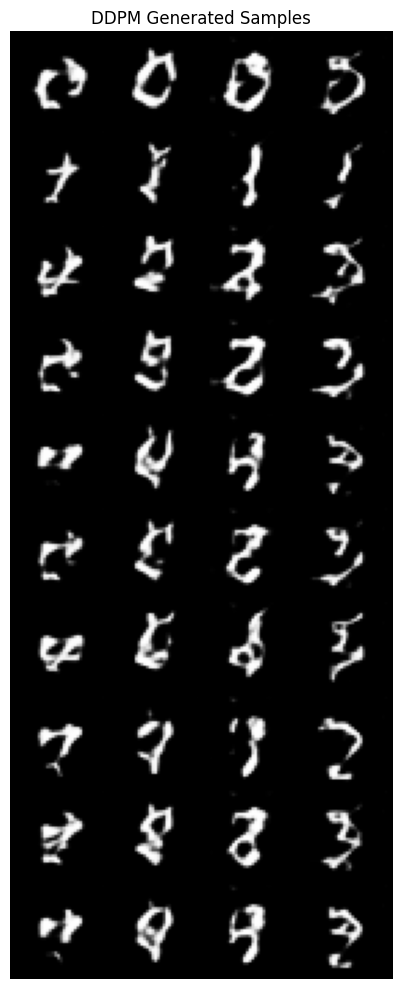

In [26]:
# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")